**Nombre:** Emilio Alejandro León Medrano **Clave única:** 225185

**Dataset a utilizar:** `hospital_staff_data_dirty.csv`

### Explicación del problema

**IMPORTANTE:** Este dataset contiene algunos problemas de calidad de datos que debes identificar y resolver antes de realizar los análisis.

El objetivo es que, como analistas de datos, sean capaces de:

* **Explorar** la información para detectar problemas de calidad.
* **Identificar** duplicados, valores faltantes, outliers e inconsistencias.
* **Limpiar** los datos aplicando técnicas apropiadas.
* **Analizar** tendencias y relaciones en los datos limpios.
* **Visualizar** los resultados con gráficas claras.
* **Interpretar** los hallazgos desde una perspectiva de negocio.

In [1]:
# librerías necesarias
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

## 1) Explorando los datos

In [2]:
# a) Crear el DataFrame con los datos del archivo: hospital_staff_data_dirty.csv
df_hospital = pd.read_csv("hospital_staff_data_dirty.csv")
df_hospital.head()

,StaffID,Name,Medical_Department,Years_Experience,Academic_Level,Age,Gender,City,Monthly_Compensation,Start_Date
0,1,Employee_1,Emergency Room,24.0,Master,37,Male,New York,113696.0,2023-08-12
1,2,Employee_2,Emergency Room,19.0,PhD,24,Male,Boston,91237.0,2020-07-02
2,3,Employee_3,ER,7.0,PhD,36,Female,Houston,25851.0,2024-01-08
3,4,Employee_4,Cardiology,11.0,Master,31,Male,Chicago,74797.0,2009-03-03
4,5,Employee_5,Pediatrics,20.0,Master,24,Female,Houston,74615.0,2008-10-07


In [3]:
# b) Indicar cuántos registros contiene el DataFrame
len(df_hospital)

53

#### El DataFrame tiene 53 registros

In [4]:
# c) Obtener y mostrar el total de valores faltantes por columna
df_hospital.isna().sum()

StaffID                 0
Name                    0
Medical_Department      0
Years_Experience        2
Academic_Level          3
Age                     0
Gender                  0
City                    0
Monthly_Compensation    2
Start_Date              0
dtype: int64

## Describe tus hallazgos del punto anterior:
#### Hay 2 registros faltantes en años de experiencia, 3 en nivel académico y 2 en compensación mensual.

## 2) Limpieza de datos y justificación

In [5]:
# a) Detectar duplicados - ¿cuántos valores duplicados hay? Responder con código.
df_hospital.duplicated()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
50     True
51     True
52    False
dtype: bool

In [6]:
df_hospital.duplicated().sum()

np.int64(2)

In [7]:
# b) Eliminar valores duplicados
df_hospital = df_hospital.drop_duplicates(keep= 'first')
df_hospital

,StaffID,Name,Medical_Department,Years_Experience,Academic_Level,Age,Gender,City,Monthly_Compensation,Start_Date
0,1,Employee_1,Emergency Room,24.0,Master,37,Male,New York,113696.0,2023-08-12
1,2,Employee_2,Emergency Room,19.0,PhD,24,Male,Boston,91237.0,2020-07-02
2,3,Employee_3,ER,7.0,PhD,36,Female,Houston,25851.0,2024-01-08
3,4,Employee_4,Cardiology,11.0,Master,31,Male,Chicago,74797.0,2009-03-03
4,5,Employee_5,Pediatrics,20.0,Master,24,Female,Houston,74615.0,2008-10-07
5,6,Employee_6,Radiology,NaN,Bachelor,26,Male,New York,35458.0,2012-03-22
6,7,Employee_7,Cardiology,9.0,PhD,45,Male,Chicago,112841.0,2012-12-27
7,8,Employee_8,Emergency Room,20.0,Bachelor,56,Male,New York,60382.0,2021-05-09
8,9,Employee_9,Surgery,22.0,Master,25,Male,Boston,77581.0,2013-01-02
9,10,Employee_10,ER,19.0,Master,35,Female,Los Angeles,109259.0,2017-04-16


In [8]:
df_hospital.duplicated().sum()

np.int64(0)

In [9]:
# c) Estandarizar la inconsistencia en la columna Medical_Department (ocurrencias de 'Emergency Room' y 'ER')
df_hospital["Medical_Department"].unique()

array(['Emergency Room', 'ER', 'Cardiology', 'Pediatrics', 'Radiology',
       'Surgery'], dtype=object)

In [10]:
# Como solamente hay una discrepancia con "Emergency Room" e "ER" lo podemos arreglar usando únicamente replace.
df_hospital.loc[:, "Medical_Department"] = df_hospital["Medical_Department"].replace("ER", "Emergency Room")
df_hospital["Medical_Department"].unique()

array(['Emergency Room', 'Cardiology', 'Pediatrics', 'Radiology',
       'Surgery'], dtype=object)

In [11]:
# d) Imputar/rellenar valores faltantes de la manera que juzgues más adecuada
df_hospital.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 52
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StaffID               51 non-null     int64  
 1   Name                  51 non-null     object 
 2   Medical_Department    51 non-null     object 
 3   Years_Experience      49 non-null     float64
 4   Academic_Level        48 non-null     object 
 5   Age                   51 non-null     int64  
 6   Gender                51 non-null     object 
 7   City                  51 non-null     object 
 8   Monthly_Compensation  49 non-null     float64
 9   Start_Date            51 non-null     object 
dtypes: float64(2), int64(2), object(6)
memory usage: 4.4+ KB


In [12]:
df_hospital.loc[df_hospital["Years_Experience"].isna()]
#Como es una serie de tipo float, creo que lo mejor es reemplazarlo con la mediana

,StaffID,Name,Medical_Department,Years_Experience,Academic_Level,Age,Gender,City,Monthly_Compensation,Start_Date
5,6,Employee_6,Radiology,NaN,Bachelor,26,Male,New York,35458.0,2012-03-22
18,19,Employee_19,Surgery,NaN,Bachelor,41,Female,Chicago,92839.0,2017-02-15


In [13]:
df_hospital.loc[:,"Years_Experience"] = df_hospital["Years_Experience"].fillna(df_hospital["Years_Experience"].median())
df_hospital.isna().sum()

StaffID                 0
Name                    0
Medical_Department      0
Years_Experience        0
Academic_Level          3
Age                     0
Gender                  0
City                    0
Monthly_Compensation    2
Start_Date              0
dtype: int64

In [14]:
df_hospital.loc[df_hospital["Academic_Level"].isna()]
#Como es una serie de tipo object, probablemente sea una serie categórica.
#Por lo que lo mejor es reemplazar con la moda

,StaffID,Name,Medical_Department,Years_Experience,Academic_Level,Age,Gender,City,Monthly_Compensation,Start_Date
10,11,Employee_11,Emergency Room,5.0,NaN,57,Female,Houston,101484.0,2015-12-16
42,43,Employee_43,Cardiology,12.0,NaN,36,Male,Boston,NaN,2014-05-13
47,48,Employee_48,Emergency Room,24.0,NaN,54,Female,Los Angeles,116384.0,2013-08-19


In [15]:
df_hospital.loc[:,"Academic_Level"] = df_hospital["Academic_Level"].fillna(df_hospital["Academic_Level"].mode()[0])
df_hospital.isna().sum()

StaffID                 0
Name                    0
Medical_Department      0
Years_Experience        0
Academic_Level          0
Age                     0
Gender                  0
City                    0
Monthly_Compensation    2
Start_Date              0
dtype: int64

In [16]:
df_hospital.loc[df_hospital["Monthly_Compensation"].isna()]

,StaffID,Name,Medical_Department,Years_Experience,Academic_Level,Age,Gender,City,Monthly_Compensation,Start_Date
32,33,Employee_33,Pediatrics,25.0,High School,22,Female,Houston,NaN,2008-08-23
42,43,Employee_43,Cardiology,12.0,Bachelor,36,Male,Boston,NaN,2014-05-13


In [17]:
df_hospital.iloc[32:43]

,StaffID,Name,Medical_Department,Years_Experience,Academic_Level,Age,Gender,City,Monthly_Compensation,Start_Date
32,33,Employee_33,Pediatrics,25.0,High School,22,Female,Houston,NaN,2008-08-23
33,34,Employee_34,Radiology,9.0,Bachelor,44,Male,New York,45676.0,2016-10-29
34,35,Employee_35,Pediatrics,20.0,High School,57,Female,Boston,42601.0,2012-12-06
35,36,Employee_36,Emergency Room,4.0,Bachelor,39,Female,Houston,69942.0,2011-07-26
36,37,Employee_37,Pediatrics,17.0,PhD,38,Male,Boston,133704.0,2013-03-16
37,38,Employee_38,Emergency Room,11.0,Bachelor,38,Male,Los Angeles,81057.0,2019-07-31
38,39,Employee_39,Emergency Room,3.0,Bachelor,56,Male,Chicago,44410.0,2016-08-21
39,40,Employee_40,Emergency Room,10.0,Master,24,Female,New York,112416.0,2009-04-22
40,41,Employee_41,Radiology,14.0,Bachelor,37,Male,New York,28248.0,2011-01-09
41,42,Employee_42,Pediatrics,14.0,Bachelor,39,Male,Boston,30075.0,2017-07-22


In [18]:
# También es una serie de tipo float, probablemente lo mejor sea reemplazarlo con la median
df_hospital.loc[:,"Monthly_Compensation"] = df_hospital["Monthly_Compensation"].fillna(df_hospital["Monthly_Compensation"].median())
df_hospital.isna().sum()

StaffID                 0
Name                    0
Medical_Department      0
Years_Experience        0
Academic_Level          0
Age                     0
Gender                  0
City                    0
Monthly_Compensation    0
Start_Date              0
dtype: int64

## [0.2] Justifica tu decisión del punto anterior: 
#### La columna de años de experiencia es de tipo float, pero no hemos visto si tiene outliers, por lo que
#### La medida más segura es la Mediana
#### La columna de nivel académico es de tipo object, probablemente categórica, por lo que
#### La medida más confiable es la moda
#### La columnade compensación, al igual que la de años, es de tipo float, por la misma razón 
#### Reemplazamos con la mediana.

In [23]:
# e) Convertir el tipo de la columna Start_Date a datetime
df_hospital["Start_Date"] = pd.to_datetime(df_hospital["Start_Date"], format = "%Y-%m-%d")
df_hospital["Start_Date"]

0    2023-08-12
1    2020-07-02
2    2024-01-08
3    2009-03-03
4    2008-10-07
5    2012-03-22
6    2012-12-27
7    2021-05-09
8    2013-01-02
9    2017-04-16
10   2015-12-16
11   2024-10-06
12   2007-04-05
13   2007-01-27
14   2020-08-28
15   2009-07-05
16   2008-07-20
17   2020-08-09
18   2017-02-15
19   2011-12-10
20   2018-07-13
21   2016-02-17
22   2008-03-19
23   2017-01-23
24   2009-03-13
25   2011-10-18
26   2017-03-16
27   2019-12-28
28   2010-07-13
29   2016-01-21
30   2020-02-03
31   2021-06-23
32   2008-08-23
33   2016-10-29
34   2012-12-06
35   2011-07-26
36   2013-03-16
37   2019-07-31
38   2016-08-21
39   2009-04-22
40   2011-01-09
41   2017-07-22
42   2014-05-13
43   2009-08-02
44   2024-08-21
45   2007-01-14
46   2020-12-22
47   2013-08-19
48   2013-10-25
49   2017-08-12
52   2010-01-15
Name: Start_Date, dtype: datetime64[ns]

In [24]:
df_hospital.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 0 to 52
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   StaffID               51 non-null     int64         
 1   Name                  51 non-null     object        
 2   Medical_Department    51 non-null     object        
 3   Years_Experience      51 non-null     float64       
 4   Academic_Level        51 non-null     object        
 5   Age                   51 non-null     int64         
 6   Gender                51 non-null     object        
 7   City                  51 non-null     object        
 8   Monthly_Compensation  51 non-null     float64       
 9   Start_Date            51 non-null     datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 4.4+ KB


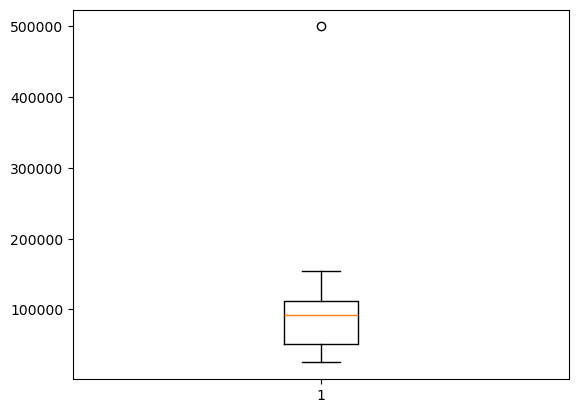

In [25]:
# f) Obtener y mostrar la ocurrencia de valores atípicos en la columna Monthly_Compensation
plt.boxplot(df_hospital["Monthly_Compensation"])
plt.show()

In [26]:
# Aparentemente hay un valor atípico, usemos IQR
Q1 = df_hospital["Monthly_Compensation"].quantile(0.25)
Q3 = df_hospital["Monthly_Compensation"].quantile(0.75)
IQR = Q3-Q1

lim_inf = Q1-1.5*IQR
lim_sup = Q3+1.5*IQR

df_hospital.loc[(df_hospital["Monthly_Compensation"]<lim_inf) | (df_hospital["Monthly_Compensation"]>lim_sup)]

,StaffID,Name,Medical_Department,Years_Experience,Academic_Level,Age,Gender,City,Monthly_Compensation,Start_Date
52,101,Executive_Hospital,Emergency Room,25.0,PhD,55,Male,Boston,500000.0,2010-01-15


##  [0.2] ¿Existen valores atípicos? SI/NO:Si

## Comenta si tendrías que eliminarlos o no (solo comenta): No, se podría reemplazar por el límite superior

## Ya se encuentran los datos limpios

## 3) Tendencia de compensación por experiencia

In [27]:
# SOLO PARA LA PREGUNTA 3.
# a) Crea un nuevo DataFrame que contenga únicamente empleados con más de 5 años de experiencia.
df_emp_sup = pd.DataFrame(df_hospital.loc[df_hospital["Years_Experience"]>5])
df_emp_sup.head()

,StaffID,Name,Medical_Department,Years_Experience,Academic_Level,Age,Gender,City,Monthly_Compensation,Start_Date
0,1,Employee_1,Emergency Room,24.0,Master,37,Male,New York,113696.0,2023-08-12
1,2,Employee_2,Emergency Room,19.0,PhD,24,Male,Boston,91237.0,2020-07-02
2,3,Employee_3,Emergency Room,7.0,PhD,36,Female,Houston,25851.0,2024-01-08
3,4,Employee_4,Cardiology,11.0,Master,31,Male,Chicago,74797.0,2009-03-03
4,5,Employee_5,Pediatrics,20.0,Master,24,Female,Houston,74615.0,2008-10-07


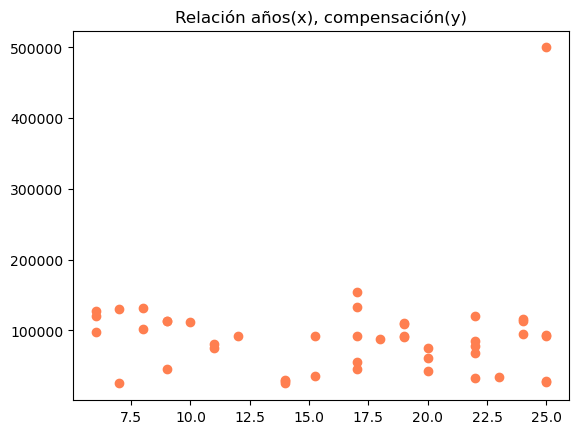

In [84]:
# b) Grafica la relación entre Years_Experience y Monthly_Compensation para los empleados con más de 5 años de experiencia.
plt.scatter(df_emp_sup["Years_Experience"], df_emp_sup["Monthly_Compensation"], color = "coral")
plt.title("Relación años(x), compensación(y)")
plt.show()

## [0.3] Explica tus resultados: No parece que haya una gran correlación entre los años de 
## experiencia con la compensación que reciben.

## 4) Distribución de géneros y análisis de experiencia promedio por ciudad

In [86]:
# a) Calcula el porcentaje de hombres y mujeres (de acuerdo a los datos registrados en la columna Gender) respecto al total de empleados, del DataFrame limpio.
total = len(df_hospital)
total_muj = len(df_hospital.loc[df_hospital["Gender"]== "Female"])
total_hom = len(df_hospital.loc[df_hospital["Gender"]== "Male"])

por_muj = total_muj/total * 100
por_hom = total_hom/total * 100

print(por_muj, por_hom)

37.254901960784316 62.745098039215684


In [31]:
# b) Determina qué departamento (Medical_Department) de cuál ciudad (City) tiene a los médicos con la mayor experiencia (Years_Experience) promedio
años = df_hospital.groupby(["Medical_Department", "City"])[["Years_Experience"]].mean()
años

Years_Experience
Medical_Department City                         
Cardiology         Boston              12.000000
                   Chicago             10.000000
                   Los Angeles         19.000000
                   New York             7.000000
Emergency Room     Boston              18.250000
                   Chicago             10.333333
                   Houston             13.625000
                   Los Angeles         19.000000
                   New York            14.800000
Pediatrics         Boston              14.750000
                   Chicago             13.000000
                   Houston             19.000000
Radiology          Boston              22.000000
                   Chicago             19.500000
                   Houston             14.000000
                   New York            13.333333
Surgery            Boston              19.500000
                   Chicago             17.000000
                   Los Angeles         14.000000

In [30]:
max = años.idxmax()
max

Years_Experience    (Radiology, Boston)
dtype: object

## Explica: Radiología en Boston tiene la de mas años de experiencia

## 5) Tabla de cantidad de registros por nivel académico y departamento

**a)** Genera una tabla con la cantidad de registros por nivel académico (High School, Bachelor, Master, PhD) registrados en la columna Academic_Level y la columna Medical_Department.

In [32]:
# a) Tabla con registros que muestre cuántos médicos hay por departamento según su nivel académico.
pd.crosstab(df_hospital["Medical_Department"], df_hospital["Academic_Level"])

Academic_Level,Bachelor,High School,Master,PhD
Medical_Department,,,,
Cardiology,2,0,2,1
Emergency Room,7,4,7,6
Pediatrics,4,3,2,1
Radiology,5,1,0,2
Surgery,1,0,1,2


## 6) Comparación de compensación promedio por nivel académico

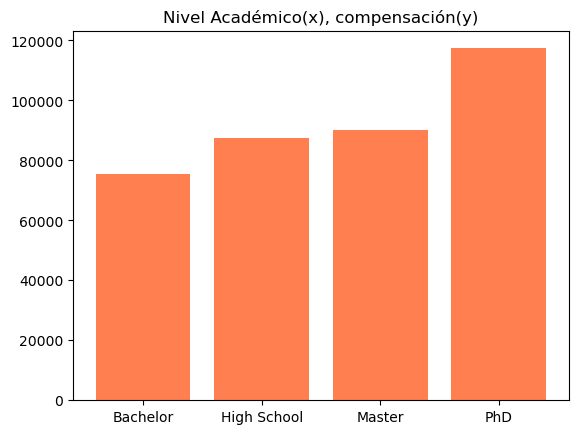

In [35]:
# a) Gráfica de barras que muestre las compensaciones (datos contenidos en la columna Monthly_Compensation) promedio registrados por cada uno de los niveles académicos registrados en la columna Academic_Level
promedio = df_hospital.groupby("Academic_Level")["Monthly_Compensation"].mean()
plt.bar(promedio.index, promedio.values, color = "coral")
plt.title("Nivel Académico(x), compensación(y)")
plt.show()

## 7) Correlaciones numéricas

**a)** Calcula la matriz de correlación entre las variables numéricas del dataframe (Age, Years_Experience, Monthly_Compensation).

**b)** ¿Qué interpretación puedes dar sobre la relación entre experiencia, edad y compensación?

In [97]:
# a) Calcular matriz de correlación
df_hospital[["Age", "Years_Experience", "Monthly_Compensation"]].corr()

,Age,Years_Experience,Monthly_Compensation
Age,1.000000,-0.072918,0.185937
Years_Experience,-0.072918,1.000000,0.083965
Monthly_Compensation,0.185937,0.083965,1.000000


## ¿Qué interpretación puedes dar? Ninguna de las correlaciones parecen estar fuertemente relacionadas.
#### La más fuerte es la edad con la compensación y aún así no es muy significativa

## 8) Exportación final

Guarda el DataFrame trabajado

In [115]:
# Exportar DataFrame limpio
df_hospital.to_csv("225185_Resultados_Hospital.csv")